# DSCI 552 — Homework 3
**Seonmin Kim**

Time Series Classification Part 1: Feature Creation/Extraction (AReM dataset), plus ISLR 3.7.4.

> Note: Part 2 (Problem 4, binary/multiclass classification) is submitted with Homework 4, per the assignment instructions.

## 1. Time Series Classification Part 1: Feature Creation/Extraction

### 1(a) Load the AReM data

The dataset contains 7 activity folders (`bending1`, `bending2`, `cycling`, `lying`, `sitting`, `standing`, `walking`) with 88 instances total. Each instance file holds 6 time series (`avg_rss12`, `var_rss12`, `avg_rss13`, `var_rss13`, `avg_rss23`, `var_rss23`) of 480 values.

**Minor cleaning needed (handled in the loader below):**
- `bending2/dataset4.csv` is space-separated instead of comma-separated.
- `cycling/dataset9.csv` and `cycling/dataset14.csv` have a trailing comma on the last row (creates an empty 8th column).
- `sitting/dataset8.csv` has 479 rows instead of 480 (one missing sample; we simply use the rows present).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 12)
rng = np.random.default_rng(42)

DATA_DIR = Path("../data/AReM")
ACTIVITIES = ["bending1", "bending2", "cycling", "lying", "sitting", "standing", "walking"]
SERIES = ["avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]


def natural_key(p):
    return int(re.search(r"\d+", p.stem).group())


def load_instance(path):
    '''Load one AReM file -> DataFrame with the 6 RSS time series.

    Handles comma- or whitespace-separated files and trailing commas.
    '''
    df = pd.read_csv(path, comment="#", header=None, sep=r"[,\s]+", engine="python",
                     names=range(8))  # 8th slot absorbs trailing commas in two cycling files
    df = df.dropna(axis=1, how="all")          # drop empty col from trailing commas
    df = df.iloc[:, 1:7]                        # drop the time column, keep 6 series
    df.columns = SERIES
    return df.astype(float)


instances = []   # list of dicts: activity, dataset number, data
for act in ACTIVITIES:
    for f in sorted((DATA_DIR / act).glob("*.csv"), key=natural_key):
        instances.append({"activity": act, "num": natural_key(f), "data": load_instance(f)})

print(f"Total instances: {len(instances)}")
print(pd.Series([i["activity"] for i in instances]).value_counts().sort_index())

Total instances: 88
bending1     7
bending2     6
cycling     15
lying       15
sitting     15
standing    15
walking     15
Name: count, dtype: int64


### 1(b) Train/test split

Test data: datasets 1 and 2 in `bending1` and `bending2`; datasets 1, 2, and 3 in the other five folders. Everything else is training data.

In [2]:
def is_test(inst):
    if inst["activity"] in ("bending1", "bending2"):
        return inst["num"] in (1, 2)
    return inst["num"] in (1, 2, 3)


train = [i for i in instances if not is_test(i)]
test = [i for i in instances if is_test(i)]
print(f"train: {len(train)} instances, test: {len(test)} instances")

train: 69 instances, test: 19 instances


### 1(c)i Time-domain features used in time series classification

Commonly used time-domain features include:

- **Minimum / Maximum** — the range extremes of the signal
- **Mean** — central tendency (DC level)
- **Median** — robust central tendency
- **Standard deviation / Variance** — spread of the signal around its mean
- **First quartile (Q1) / Third quartile (Q3)** and the **interquartile range (IQR)** — robust spread
- **Range** (max − min)
- **Skewness** — asymmetry of the amplitude distribution
- **Kurtosis** — tailedness/peakedness of the distribution
- **Root mean square (RMS)** — signal energy
- **Mean absolute deviation (MAD)**
- **Zero-crossing rate / mean-crossing rate** — oscillation frequency in the time domain
- **Autocorrelation coefficients** — temporal self-similarity
- **Peak-to-peak amplitude, slope / mean of first differences**

Per the assignment, we extract **minimum, maximum, mean, median, standard deviation, first quartile, and third quartile** for each of the 6 time series.

### 1(c)ii Extract the time-domain features

Seven features × six time series = 42 features per instance, for all 88 instances. Features are used directly (no normalization), since the RSS series are all on the same measurement scale.

In [3]:
FEATS = ["min", "max", "mean", "median", "std", "1st_quart", "3rd_quart"]


def extract_features(ts_df):
    '''42 time-domain features from one instance (6 series x 7 features).'''
    out = {}
    for k, col in enumerate(ts_df.columns, start=1):
        s = ts_df[col]
        out[f"min{k}"] = s.min()
        out[f"max{k}"] = s.max()
        out[f"mean{k}"] = s.mean()
        out[f"median{k}"] = s.median()
        out[f"std{k}"] = s.std()
        out[f"1st_quart{k}"] = s.quantile(0.25)
        out[f"3rd_quart{k}"] = s.quantile(0.75)
    return out


feature_df = pd.DataFrame([extract_features(i["data"]) for i in instances])
feature_df.insert(0, "activity", [i["activity"] for i in instances])
feature_df.index = pd.RangeIndex(1, len(feature_df) + 1, name="Instance")

print(feature_df.shape)
feature_df

(88, 43)


,activity,min1,max1,mean1,median1,std1,...,max6,mean6,median6,std6,1st_quart6,3rd_quart6
Instance,,,,,,,,,,,,,
1,bending1,37.25,45.00,40.624792,40.50,1.476967,...,1.92,0.570583,0.43,0.582915,0.0000,1.3000
2,bending1,38.00,45.67,42.812812,42.50,1.435550,...,3.11,0.571083,0.43,0.601010,0.0000,1.3000
3,bending1,35.00,47.40,43.954500,44.33,1.558835,...,1.79,0.493292,0.43,0.513506,0.0000,0.9400
4,bending1,33.00,47.75,42.179812,43.50,3.670666,...,2.18,0.613521,0.50,0.524317,0.0000,1.0000
5,bending1,33.00,45.75,41.678063,41.75,2.243490,...,1.79,0.383292,0.43,0.389164,0.0000,0.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,walking,19.50,45.33,33.586875,34.25,4.650935,...,8.32,3.259729,3.11,1.640243,2.0500,4.3225
85,walking,19.75,45.50,34.322750,35.25,4.752477,...,9.67,3.432563,3.20,1.732727,2.1575,4.5650
86,walking,19.50,46.00,34.546229,35.25,4.842294,...,10.00,3.338125,3.08,1.656742,2.1600,4.3350


### 1(c)iii Standard deviation of each feature + 90% bootstrap confidence interval

For each of the 42 extracted features, we estimate its standard deviation across the 88 instances, and build a 90% bootstrap confidence interval for that standard deviation (percentile method, 1000 bootstrap resamples).

In [4]:
N_BOOT = 1000


def bootstrap_ci_std(values, n_boot=N_BOOT, alpha=0.10):
    values = np.asarray(values)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot_stds = values[idx].std(axis=1, ddof=1)
    lo, hi = np.percentile(boot_stds, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi


rows = []
for col in feature_df.columns.drop("activity"):
    v = feature_df[col].to_numpy()
    lo, hi = bootstrap_ci_std(v)
    rows.append({"feature": col, "std": v.std(ddof=1), "CI_lower(5%)": lo, "CI_upper(95%)": hi})

std_ci = pd.DataFrame(rows).set_index("feature").round(4)
std_ci

,std,CI_lower(5%),CI_upper(95%)
feature,,,
min1,9.5700,8.2096,10.7872
max1,4.3944,3.3346,5.3046
mean1,5.3357,4.6945,5.8481
median1,5.4401,4.7835,6.0017
std1,1.7722,1.5637,1.9515
1st_quart1,6.1536,5.5835,6.6225
3rd_quart1,5.1389,4.3028,5.8666
min2,0.0000,0.0000,0.0000
max2,5.0627,4.6123,5.4064


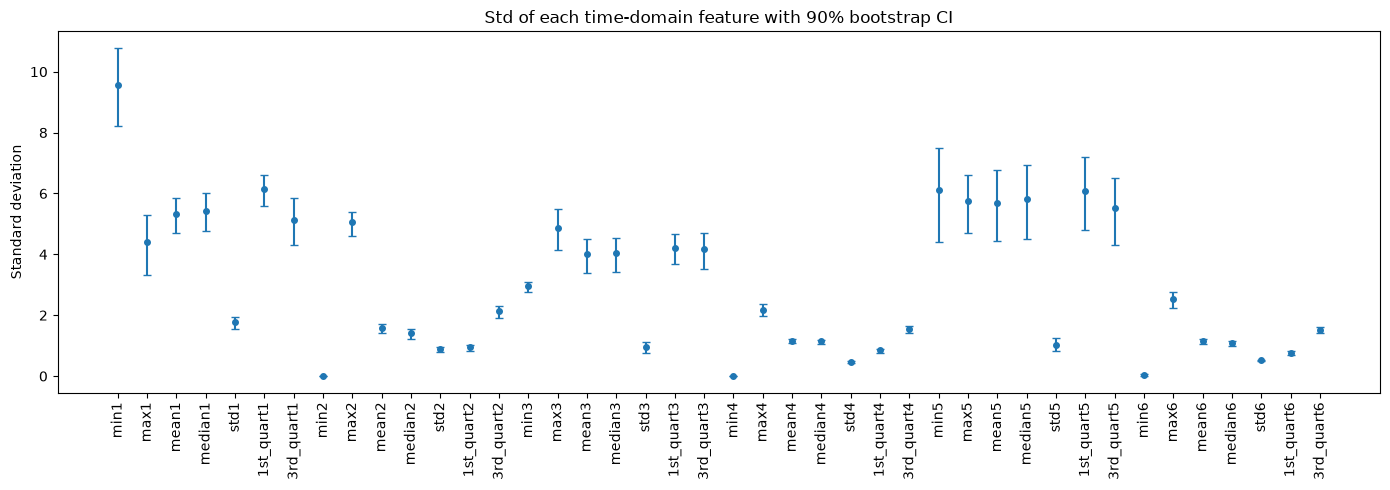

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(std_ci))
ax.errorbar(x, std_ci["std"],
            yerr=[std_ci["std"] - std_ci["CI_lower(5%)"], std_ci["CI_upper(95%)"] - std_ci["std"]],
            fmt="o", ms=4, capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(std_ci.index, rotation=90)
ax.set_ylabel("Standard deviation")
ax.set_title("Std of each time-domain feature with 90% bootstrap CI")
plt.tight_layout()
plt.show()

### 1(c)iv The three most important time-domain features

Looking at the standard deviations and their confidence intervals above, the features that vary the most across instances — and therefore carry the most discriminative information between activities — are consistently the **minimum, mean, and maximum** of the series (especially of `avg_rss12`, `avg_rss13`, and `avg_rss23`):

- **Mean** captures the overall RSS level of an activity, which differs strongly between static postures (lying, sitting, standing) and dynamic activities (walking, cycling).
- **Minimum** and **Maximum** capture the extremes of the signal; dynamic activities produce much wider swings than static ones.

The median is nearly redundant with the mean (highly correlated), and Q1/Q3 are largely captured by min/max/std. So we select:

> **Selected features: `min`, `mean`, `max`** (for each time series).

## 2. ISLR 3.7.4

We collect data for \(n = 100\) observations and fit (i) a linear regression \(Y = \beta_0 + \beta_1 X + \varepsilon\) and (ii) a cubic regression \(Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon\).

**(a) True relationship is linear — training RSS.**
We would expect the **cubic regression's training RSS to be lower than (or at worst equal to) the linear one's**. The cubic model contains the linear model as a special case (\(\beta_2 = \beta_3 = 0\)), so with its extra flexibility it can always fit the training data at least as well. Least squares will exploit that flexibility to chase noise, reducing training RSS even though the true relationship is linear.

**(b) True relationship is linear — test RSS.**
We would expect the **linear regression's test RSS to be lower**. Since the true relationship is linear, the cubic model's extra terms only fit noise in the training set (overfitting). This increases variance without reducing bias, so the cubic model generalizes worse to unseen data.

**(c) True relationship is non-linear (unknown how far from linear) — training RSS.**
The **cubic regression's training RSS will again be lower (or equal)**. This holds regardless of the true relationship: the more flexible model always achieves training RSS at least as low as any model nested inside it.

**(d) True relationship is non-linear — test RSS.**
**There is not enough information to tell.** It depends on how far the true relationship is from linear:
- If it is only slightly non-linear, the linear model's lower variance may win, giving it a lower test RSS.
- If it is strongly non-linear (e.g., close to cubic), the cubic model's lower bias dominates and its test RSS will be lower.

This is the bias–variance trade-off: without knowing the true functional form (and the noise level), we cannot say which model has the lower test RSS.